In [3]:
import pandas as pd

In [7]:
orders_qu=pd.read_csv("orders_qu.csv")
orderlines_qu=pd.read_csv("orderlines_qu.csv")
products_cl=pd.read_csv("products_cl.csv")

So we've loaded the files, and need to look at the discounts. This can be done by comparing the prices in orderlines with the prices in products. To simplify analysis, we might just as well merge everything together.

discount should be products_cl["price"]-orderlines_cl["price"]

In [12]:
orderlines_qu.info()

<class 'pandas.DataFrame'>
RangeIndex: 53231 entries, 0 to 53230
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                53231 non-null  int64  
 1   id_order          53231 non-null  int64  
 2   product_id        53231 non-null  int64  
 3   product_quantity  53231 non-null  int64  
 4   sku               53231 non-null  str    
 5   unit_price        53231 non-null  float64
 6   date              53231 non-null  str    
dtypes: float64(1), int64(4), str(2)
memory usage: 2.8 MB


In [15]:
merge_df=orders_qu.merge(orderlines_qu, how="left", left_on="order_id", right_on="id_order").merge(products_cl, how="left", on="sku")

ok, we have a big file now. We could drop some info, like the empty "product id" column, or the duplicated "order id", but we might as well keep everything for now to make splitting easier if required later. Instead, lets now figure out the rebates.

In [22]:
merge_df["discount"] = merge_df["price"]-merge_df["unit_price"]

In [25]:
merge_df["discount"].describe()

count    53231.000000
mean        26.116673
std         45.545881
min       -170.990000
25%          5.250000
50%         15.000000
75%         31.000000
max       1320.000000
Name: discount, dtype: float64

Ok, some basic questions from the LMS:

What is the time period that the dataset covers?
What is the overall revenue for that time?
Are there seasonal patterns in the evolution of sales?
What are the most sold products?
What are the products that generate the most revenue?

Lets check them in order.

In [26]:
merge_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53231 entries, 0 to 53230
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          53231 non-null  int64  
 1   created_date      53231 non-null  str    
 2   total_paid        53231 non-null  float64
 3   state             53231 non-null  str    
 4   id                53231 non-null  int64  
 5   id_order          53231 non-null  int64  
 6   product_id        53231 non-null  int64  
 7   product_quantity  53231 non-null  int64  
 8   sku               53231 non-null  str    
 9   unit_price        53231 non-null  float64
 10  date              53231 non-null  str    
 11  name              53231 non-null  str    
 12  desc              53231 non-null  str    
 13  price             53231 non-null  float64
 14  in_stock          53231 non-null  int64  
 15  type              53220 non-null  str    
 16  discount          53231 non-null  float64
dtypes: f

In [29]:
lastdate=merge_df["created_date"].max()
firstdate=merge_df["created_date"].min()
print(firstdate, lastdate)

2017-01-01 01:51:47 2018-03-14 12:03:52


Ok, so we have the time period. Lets total the sales.

In [37]:
total_sales = sum(merge_df.groupby("order_id")["total_paid"].max().tolist())
print(f"Total sales over the period {firstdate} to {lastdate} is {total_sales}")

Total sales over the period 2017-01-01 01:51:47 to 2018-03-14 12:03:52 is 7978675.6


And below just checking directly in the orders table:

In [50]:
orders_qu["total_paid"].sum()

np.float64(7978675.6)

OK, so here below we see total sales over time. The drop duplicates is due to my merged file - you could skip all of that and just work with the orders table. Note that we have to do to_datetime() again even if we did it the other day - the data type is NOT saved in the .csv format. Remember that the resample method is basically groupby specially adapted to time series. Here the "ME" denotes Month's End - so basically we bin things monthly. If you change the resolution to like "D" for day (Try it!) you can clearly see like Black Friday.

<Axes: xlabel='created_date'>

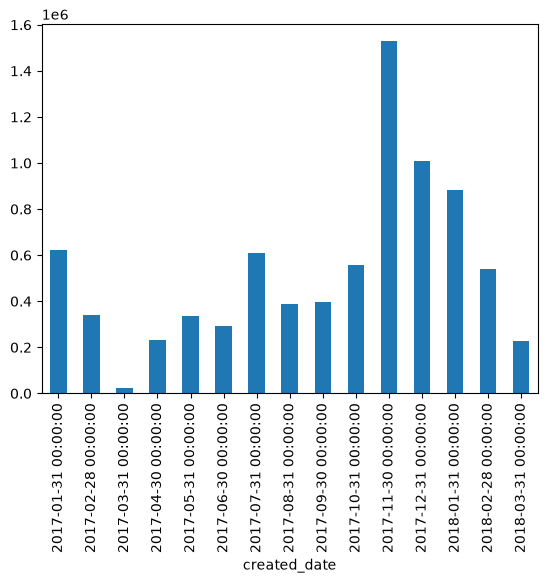

In [72]:
merge_df["created_date"] = pd.to_datetime(merge_df["created_date"])
orders_unique = merge_df.drop_duplicates(subset="order_id")
orders_unique.resample("ME", on="created_date")["total_paid"].sum().plot(kind="bar")

Ok below is the discount in percentage, because I like it that way, and it feels more significant in general for grouping later.

In [80]:
merge_df["discount_percentage"] = ((merge_df["discount"] / merge_df["price"]) * 100).round(2)

Below a similar graph to the one above, but this one tracks average discounts over the entire stock. Again you can play with resolution, changing to day makes it ugly, but telling.

<Axes: xlabel='created_date'>

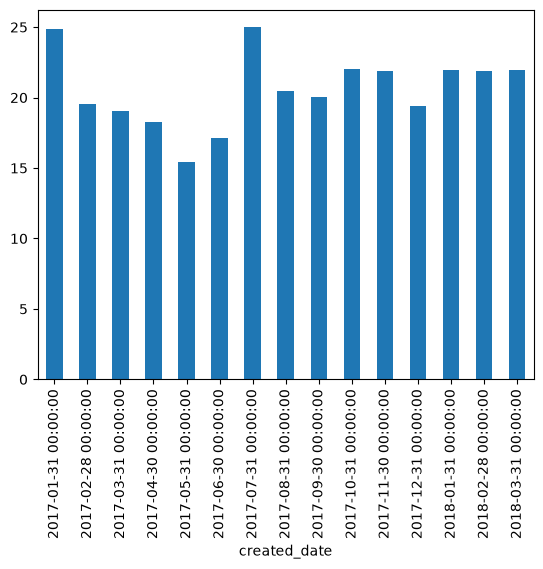

In [119]:
merge_df.resample("ME", on="created_date")["discount_percentage"].mean().plot(kind="bar")

Ok, so lets figure out which products are our bestsellers - first in terms of pure numbers. Below one version for orderlines, and one for our merged file. They are equivalent.

<Axes: ylabel='sku'>

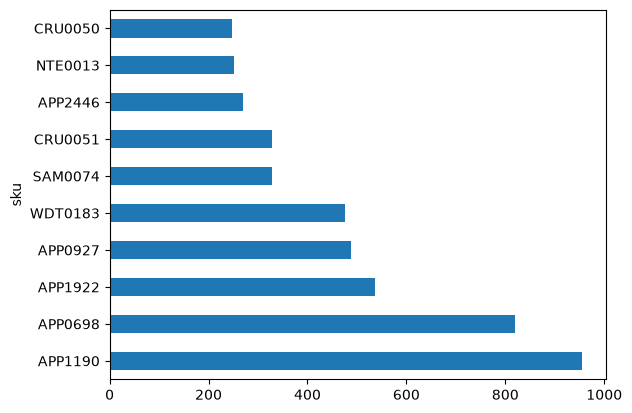

: 

In [ ]:
orderlines_qu.groupby("sku")["product_quantity"].sum().sort_values(ascending=False).head(10).plot(kind="barh")

<Axes: ylabel='sku'>

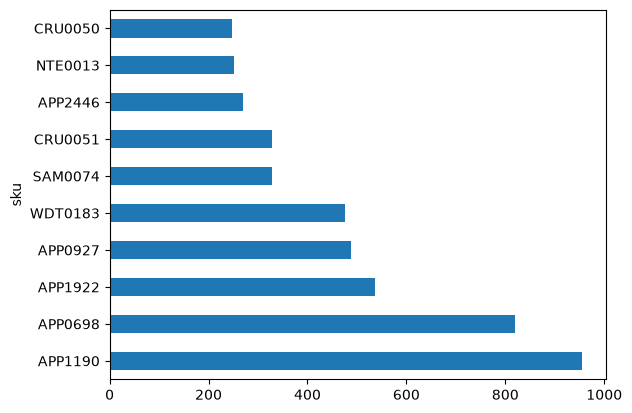

In [46]:
merge_df.groupby("sku")["product_quantity"].sum().sort_values(ascending=False).head(10).plot(kind="barh")

Ok cool, but if you look those SKUs up, they'll be like cheap USB cables or some such. Exercise - also pull in the product names. Wait, lets try that here below:

<Axes: ylabel='sku,name'>

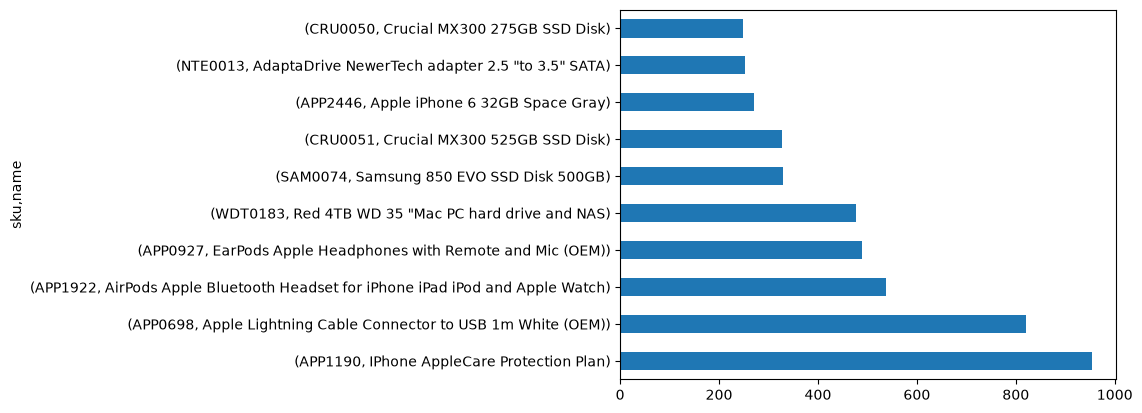

In [122]:
merge_df.groupby(["sku", "name"])["product_quantity"].agg("sum").sort_values(ascending=False).head(10).plot(kind="barh")

Ok, so have a quick think why grouping for both works so nicely (generally it wouldn't). Solution: SKU and name are in a 1-1 correspondance.

Ok, now lets check which products drive revenue instead. Here we'll work with prices, so lets first account for sales in multiples, and then do the same kind of chart as above.

In [47]:
merge_df["total_sale_price"] = merge_df["unit_price"] * merge_df["product_quantity"]

<Axes: ylabel='sku,name'>

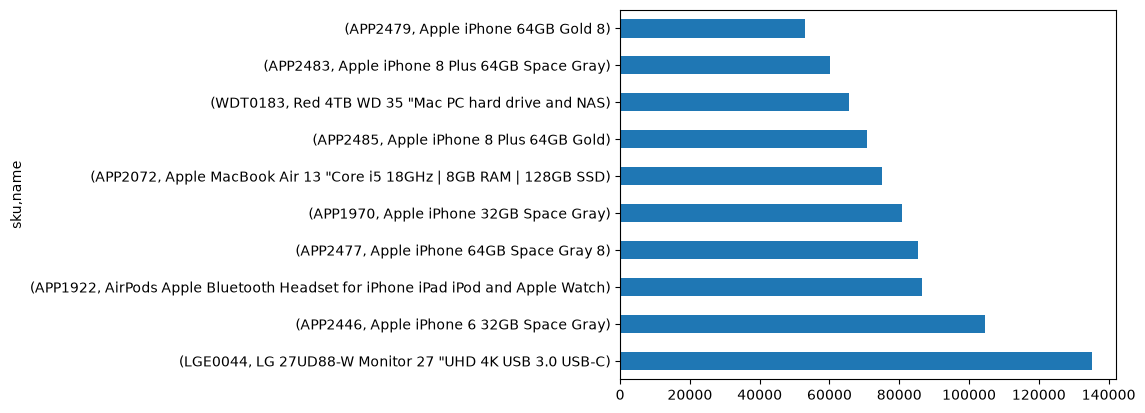

In [123]:
merge_df.groupby(["sku", "name"])["total_sale_price"].sum().sort_values(ascending=False).head(10).plot(kind="barh")

Cool, those would be our revenue drivers. If you kill the .plot, and change the argument in .head, you can easily pull a larger range of high earners for further analysis. THing to try: Do this with like the upper quartile (quartiles are built in!) or like with the upper 20% to check the pareto principle.

Things to try: Maybe look at individual items, when are they sold? Like when they selling? What proportions of sales are with discounts? Maybe with examples of high and low earners, high and low cost items etc. First lets redo the table above with more data, and name them in case I want to reuse them later.

In [124]:
top10 = merge_df.groupby(["sku", "name"]).agg({"total_sale_price": "sum", "price": "first", "product_quantity": "sum"}).sort_values("total_sale_price", ascending=False).head(10)

In [125]:
top10

,,total_sale_price,price,product_quantity
sku,name,,,
LGE0044,"LG 27UD88-W Monitor 27 ""UHD 4K USB 3.0 USB-C",135375.83,599.00,239
APP2446,Apple iPhone 6 32GB Space Gray,104560.64,449.33,270
APP1922,AirPods Apple Bluetooth Headset for iPhone iPad iPod and Apple Watch,86473.26,179.00,537
APP2477,Apple iPhone 64GB Space Gray 8,85301.93,809.00,108
APP1970,Apple iPhone 32GB Space Gray,80715.76,419.00,223
APP2072,"Apple MacBook Air 13 ""Core i5 18GHz | 8GB RAM | 128GB SSD",74964.06,1105.59,77
APP2485,Apple iPhone 8 Plus 64GB Gold,70721.79,919.00,79
WDT0183,"Red 4TB WD 35 ""Mac PC hard drive and NAS",65589.96,169.00,476
APP2483,Apple iPhone 8 Plus 64GB Space Gray,60090.08,919.00,67


We can do an individual analysis. Like that that monitor that is our best earner, LGE044. When does it sell? Which discounts drive sales, if any?

In [100]:
merge_df.loc[merge_df["sku"]=="LGE0044", ["name", "total_sale_price", "product_quantity", "discount_percentage"]].groupby("discount_percentage").agg({"total_sale_price": "sum", "product_quantity": "sum"}).sort_values("discount_percentage", ascending=False)

,total_sale_price,product_quantity
discount_percentage,,
11.07,532.67,1
10.96,3200.22,6
8.35,25254.00,46
7.21,555.83,1
6.51,25759.54,46
6.24,1123.24,2
6.18,5619.90,10
5.79,1128.58,2
5.27,2837.05,5


Ok, that code might take some parsing, but it is not difficult - I simply group all the sales of it along the different prices it got sold at, but describe them in percentages against the catalog price. Why no 0.0 appears I have no idea - perhaps it is always discounted to some extent (check!) or perhaps the price recently got raised so that the lower discounts here represents older price points. Anyway, lets graph this:

<Axes: xlabel='discount_percentage'>

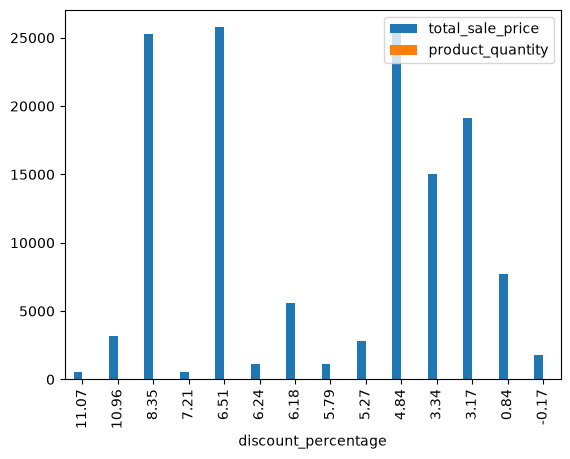

In [104]:
merge_df.loc[merge_df["sku"]=="LGE0044", ["name", "total_sale_price", "product_quantity", "discount_percentage"]].groupby("discount_percentage").agg({"total_sale_price": "sum", "product_quantity": "sum"}).sort_values("discount_percentage", ascending=False).plot(kind="bar")

Ok, so it looks kinda like some discount helps? Maybe? Things to think about for further analysis: How long were the windows of higher discount, does the frequency of sales rise? (THAT SOUDNS LIKE AN IMPORTANT THING TO TRY BUT DIFFICULT). How do the other top earners look? Try individually and with the Top10 (.isin would help here), and maybe with upper quartile.

As a first step, and last analysis for the day, here is a fun one for the entire sortiment. We can bin discounts into ranges of 10, see the first code line below (note: you could also start at like -10 or -20 or so, an oddly large amount of sales have a negative discount. I assume they correspond to older, permanently higher price points).

The second line is just a nice groupby on these bins, and we look at total sales in euros and units. This is for the everything at once, but should be repeated with different segments (in terms of earnings and sales, think quartiles or such).

In [118]:
merge_df["discount_bin"] = pd.cut(merge_df["discount_percentage"], bins=range(0, 101, 10))

merge_df.groupby("discount_bin", observed=True).agg(total_sale_price=("total_sale_price", "sum"), product_quantity=("product_quantity", "sum"))


,total_sale_price,product_quantity
discount_bin,,
"(0, 10]",2681656.53,12254
"(10, 20]",2569012.88,17208
"(20, 30]",1386790.69,12379
"(30, 40]",339697.43,5034
"(40, 50]",114120.63,3017
"(50, 60]",73018.05,2239
"(60, 70]",43060.82,2097
"(70, 80]",29836.54,1053
"(80, 90]",2408.50,352


A quick look tellls us that the vast majority of our sales occur at no, or a smaller < 30% discount... that might not be that telling though, compare and contrast with the spread of discounts over time as a share...

Ok, there you have a few ideas for further analysis, and some examples of code (probably clunky, but eh).